## Modern Coexistence Theory (MCT): Application to non-essential cross-feeding model
In this workbook we demonstrate the mapping between the mechanistic cross-feeding model and MCT through the two-species gLV-based definition of niche overlap and fitness ratio. In contrast to the other demonstration of this process available in this repository (AuxotrophyModelConstructionDemo.ipynb), here we demonstrate this procedure for another model: the non-essential cross-feeding model of __[Goldford et al.](https://doi.org/10.1126/science.aat1168)__.

This is used to generate Fig S8.

In [1]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [2]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    C = EOparams['C']
    delW = EOparams['delW']
    
    sens = sum([rs[rho]*C[specInd,rho]*delW[specInd,rho] for rho in range(len(rs))])

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    C = EOparams['C']
    delW = EOparams['delW']
    
    sensGrad = np.array([C[specInd,rho]*delW[specInd,rho] for rho in range(len(rs))])
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    C = EOparams['C']
    Dar = EOparams['Dar']
    
    impact = np.array([-C[specInd,rho]*rs[rho] + sum([Dar[specInd,rho,thet]*C[specInd,thet]*rs[thet] for thet in range(len(rs))]) for rho in range(len(rs))])

    return impact

#Predicted steady-state chemostat resource concs.
def findRstar(EOparams,sysParams):
    C = EOparams['C']
    delW = EOparams['delW']
    D = sysParams['D']

    Cw = np.array([[C[alph,rho]*delW[alph,rho] for alph in range(len(B0))] for rho in range(len(rIn))])
    return np.linalg.solve(Cw.T, np.ones(B0.shape)*D)

#Instantaneous interaction of beta acting on alpha
def instInteract(rs,alphInd,betInd,EOparams):
    C = EOparams['C']
    delW = EOparams['delW']
    Dar = EOparams['Dar']
    
    c = np.array([C[alphInd,rho]*C[betInd,rho]*delW[alphInd,rho]*rs[rho] for rho in range(len(rs))])
    p = np.array([sum([Dar[betInd,rho,thet]*C[betInd,thet]*C[alphInd,rho]*delW[alphInd,rho]*rs[thet] for thet in range(len(rs))]) for rho in range(len(rs))])
    netInt = p-c
    
    return sum(netInt)

#How is GR of alpha being accelerated by source term?
def intrinsicGR(rs,specInd,EOparams,sysParams):
    C = EOparams['C']
    delW = EOparams['delW']
    D = sysParams['D']
    rIn = sysParams['rIn']
    
    intGR = sum([C[specInd,rho]*delW[specInd,rho]*(rIn[rho]-rs[rho])*D for rho in range(len(rs))])
    
    return intGR

In [51]:
C = np.array([[1,0.35],[0.5,1]]); #Index 1 is the species, index 2 is the resource
Dar = np.array([[[0,0.15],[0.15,0]],[[0,0.25],[0.25,0]]]) #Index 1 is the species, index 2 is consumed resource, index 3 is produced resource. Note when index 2 == index 3, value should be zero (no self-production)
delW = 1-np.squeeze(np.sum(Dar,axis=2))
EOparams = {'C':C,'Dar':Dar,'delW':delW}

noSpec = 2
noRes = 2

DilRate = 0.05

C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:39: RuntimeWarning: invalid value encountered in scalar divide
  rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:41: RuntimeWarning: invalid value encountered in scalar divide
  fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:39: RuntimeWarning: invalid value encountered in sqrt
  rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:41: RuntimeWarning: invalid value encountered in sqrt
  fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:93: RuntimeWarning: invalid value encountered in scalar divide
  rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3262372965.py:94: 

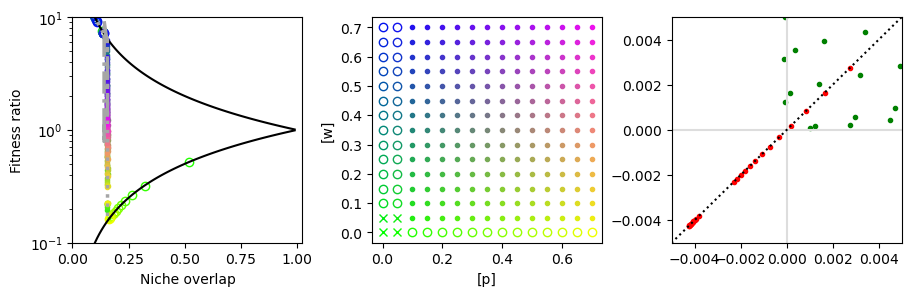

In [23]:
fig, axAr = plt.subplots(nrows = 1, ncols = 3, constrained_layout = True, figsize=(9,2.85))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

B0 = np.array([0.2,0.2])

noPts = 15

#Lattice of different concentrations
for i in range(noPts):
    for j in range(noPts):
        proConc = i*0.05
        tryConc = j*0.05

        rIn = np.array([proConc,tryConc])
        sysParams = {'rIn':rIn}
    
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
    
        chemSim.simEOmodel('Chemostat')
    
        chemSim.rStar = chemSim.resTimeseries[:,-1]
        A = chemSim.assembleIntMat(chemSim.rStar)
        mu = chemSim.assembleGRvec(chemSim.rStar)

        #These metrics are not valid if you have non-competitive interaction values. Flag systems with net + values
        if np.sum(np.sum(A<0)) < 4:
            NAflag = True
        else:
            NAflag = False
    
        coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
        
        rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
        #fitRat = np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        #fitRat = mu[0]/mu[1]

        colVec = np.array([i/(noPts),1-j/(noPts),j/(noPts)])
        if coexists == 1:
            if not(NAflag):
                ax1.plot(rho,fitRat,'o',color=colVec,fillstyle='none')
                
            ax2.plot(proConc,tryConc,'o',color=colVec,fillstyle='none')
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 2:
            if not(NAflag):
                ax1.plot(rho,fitRat,'.',color=colVec)
                
            ax2.plot(proConc,tryConc,'.',color=colVec)
            
            if NAflag:
                ax2.plot(proConc,tryConc,'o',color=colVec)
                
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 0:
            ax2.plot(proConc,tryConc,'x',color=colVec)

fitRatsIsoRat = np.zeros((noPts*10))
rhosIsoRat = np.zeros((noPts*10))

#Sweep through total concentrations at fixed (1:1) ratio of input amino acids
for i in range(noPts*10):
    proConc = i*0.005
    tryConc = i*0.005

    rIn = np.array([proConc,tryConc])
    sysParams = {'rIn':rIn}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
    
    rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

fitRatsIsoTotal = np.zeros((noPts*10))
rhosIsoTotal = np.zeros((noPts*10))

#Sweep through concentration ratios at fixed total concentration (0.5)
for i in range(noPts*10):
    proConc = i*0.0046667
    tryConc = 0.7-proConc

    rIn = np.array([proConc,tryConc])
    sysParams = {'rIn':rIn}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
    
    rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoTotal[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

ax1.plot(np.arange(0.01,1,0.01),1/np.arange(0.01,1,0.01),'k')
ax1.plot(np.arange(0.01,1,0.01),np.arange(0.01,1,0.01),'k')
ax1.plot(rhosIsoRat,fitRatsIsoRat,'-.',color=(0.65,0.65,0.65),lw=2.5)
ax1.plot(rhosIsoTotal,fitRatsIsoTotal,':',color=(0.65,0.65,0.65),lw=2.5)
ax1.set_ylim([0.1,10])
ax1.set_xlim([-0,1.025])
ax1.set_yscale('log')
ax1.set_xlabel('Niche overlap')
ax1.set_ylabel('Fitness ratio')

#ax2.set_xscale('log')
#ax2.set_yscale('log')
ax2.set_xlabel('[p]')
ax2.set_ylabel('[w]')

ax3.plot([-0.02,0.02],[0,0],color = '#dddddd')
ax3.plot([0,0],[-0.02,0.02],color = '#dddddd')
ax3.plot([-0.02,0.02],[-0.02,0.02],'k:')
ax3.set_ylim([-0.005,0.005])
ax3.set_xlim([-0.005,0.005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\GoldfordMCT.pdf")

C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:43: RuntimeWarning: invalid value encountered in sqrt
  rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:45: RuntimeWarning: invalid value encountered in sqrt
  fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:98: RuntimeWarning: invalid value encountered in sqrt
  rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:99: RuntimeWarning: invalid value encountered in sqrt
  fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:126: RuntimeWarning: invalid value encountered in sqrt
  rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_10216\3467253127.py:127: Run

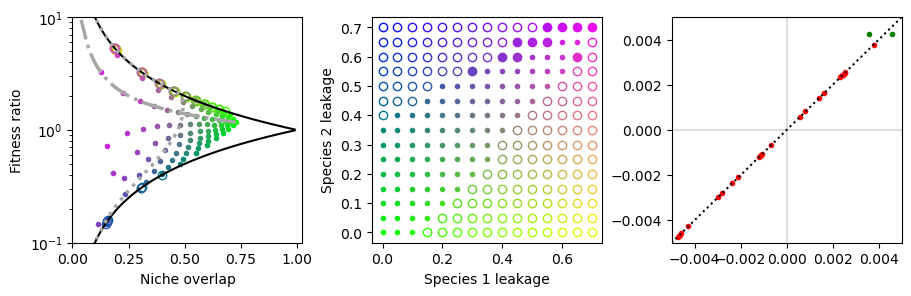

In [59]:
fig, axAr = plt.subplots(nrows = 1, ncols = 3, constrained_layout = True, figsize=(9,2.85))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

B0 = np.array([1,1])

noPts = 15

rIn = np.array([0.3,0.3])
sysParams = {'rIn':rIn}

#Logged version of the same
for i in range(noPts):
    for j in range(noPts):
        leakDelTry = i*0.05
        leakDelPro = j*0.05
        
        Dar = np.array([[[0,leakDelTry],[leakDelTry,0]],[[0,leakDelPro],[leakDelPro,0]]]) #Index 1 is the species, index 2 is consumed resource, index 3 is produced resource. Note when index 2 == index 3, value should be zero (no self-production)
        delW = 1-np.squeeze(np.sum(Dar,axis=2))
        EOparams = {'C':C,'Dar':Dar,'delW':delW}
    
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
    
        chemSim.simEOmodel('Chemostat')
    
        chemSim.rStar = chemSim.resTimeseries[:,-1]
        A = chemSim.assembleIntMat(chemSim.rStar)
        mu = chemSim.assembleGRvec(chemSim.rStar)

        #These metrics are not valid if you have non-competitive interaction values. Flag systems with net + values
        if np.sum(np.sum(A<0)) < 4:
            NAflag = True
        else:
            NAflag = False
    
        coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
        
        rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
        #fitRat = np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        #fitRat = mu[0]/mu[1]

        colVec = np.array([i/(noPts),1-j/(noPts),j/(noPts)])
        if coexists == 1:
            if not(NAflag):
                ax1.plot(rho,fitRat,'o',color=colVec,fillstyle='none')
            
            ax2.plot(leakDelTry,leakDelPro,'o',color=colVec,fillstyle='none')
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 2:
            if not(NAflag):
                ax1.plot(rho,fitRat,'.',color=colVec)
                
            ax2.plot(leakDelTry,leakDelPro,'.',color=colVec)
            
            if NAflag:
                ax2.plot(leakDelTry,leakDelPro,'o',color=colVec)
            
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 0:
            ax2.plot(leakDelTry,leakDelPro,'x',color=colVec)

fitRatsIsoRat = np.zeros((noPts*10))
rhosIsoRat = np.zeros((noPts*10))


for i in range(noPts*10):
    leakDelTry = i*0.005
    leakDelPro = i*0.005

    Dar = np.array([[[0,leakDelTry],[leakDelTry,0]],[[0,leakDelPro],[leakDelPro,0]]]) #Index 1 is the species, index 2 is consumed resource, index 3 is produced resource. Note when index 2 == index 3, value should be zero (no self-production)
    delW = 1-np.squeeze(np.sum(Dar,axis=2))
    EOparams = {'C':C,'Dar':Dar,'delW':delW}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
    
    rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

fitRatsIsoTotal = np.zeros((noPts*10))
rhosIsoTotal = np.zeros((noPts*10))

for i in range(noPts*10):
    leakDelTry = i*0.005
    leakDelPro = 0.75-leakDelTry

    Dar = np.array([[[0,leakDelTry],[leakDelTry,0]],[[0,leakDelPro],[leakDelPro,0]]]) #Index 1 is the species, index 2 is consumed resource, index 3 is produced resource. Note when index 2 == index 3, value should be zero (no self-production)
    delW = 1-np.squeeze(np.sum(Dar,axis=2))
    EOparams = {'C':C,'Dar':Dar,'delW':delW}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
    
    rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoTotal[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))


ax1.plot(np.arange(0.01,1,0.01),1/np.arange(0.01,1,0.01),'k')
ax1.plot(np.arange(0.01,1,0.01),np.arange(0.01,1,0.01),'k')
ax1.plot(rhosIsoRat,fitRatsIsoRat,'-.',color=(0.65,0.65,0.65),lw=2.5)
ax1.plot(rhosIsoTotal,fitRatsIsoTotal,':',color=(0.65,0.65,0.65),lw=2.5)
ax1.set_ylim([0.1,10])
ax1.set_xlim([-0,1.025])
ax1.set_yscale('log')
ax1.set_xlabel('Niche overlap')
ax1.set_ylabel('Fitness ratio')

#ax2.set_xscale('log')
#ax2.set_yscale('log')
ax2.set_xlabel('Species 1 leakage')
ax2.set_ylabel('Species 2 leakage')

ax3.plot([-0.02,0.02],[0,0],color = '#dddddd')
ax3.plot([0,0],[-0.02,0.02],color = '#dddddd')
ax3.plot([-0.02,0.02],[-0.02,0.02],'k:')
ax3.set_ylim([-0.005,0.005])
ax3.set_xlim([-0.005,0.005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\GoldfordMCT2.pdf")